## Sample and Calibrator Dispersion in the Candia dataset

### Background

The Candia *et al.* dataset has multiple different sample types within it. Two of the most interesting are the actual patient samples and the pooled patient samples that are used as calibrators. Within both of these catagories there are repeated measurements which can be used to evaluate CV of the assay. For the calibrators, CV is likely evaluated in the started fashion as just $cv = \bar{X}_n/\bar{S}_n$, i.e. the sample mean divided by the sample standard deviation. However, for the patient samples, I am worried this will be overdispersed because of the patient variation in expression. Below, I will dig into both situations.

### Setup

Here I will load the fully normalized data from Candia *et al.*.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy as sc
import seaborn as sns

In [2]:
samples = pd.read_table("../data/candia/sample.txt")
somamer = pd.read_table("../data/candia/somamer.txt")
measurements = pd.read_table("../data/candia/RFU_hyb.msnCal.ps.cal.msnAll.txt", header=None)

measurements.columns = somamer["SeqId"]
measurements = pd.concat(
    [measurements, samples[["PlateId", "PlatePosition"]]],
    axis=1
)
measurements = measurements.melt(id_vars = ["PlateId", "PlatePosition"], var_name="SeqId")

In [3]:
samples

,PlateId,PlateRunDate,ScannerID,PlatePosition,SlideId,Subarray,SampleId,SampleType,PercentDilution,SampleMatrix,...,SubjectID,CLI,RMA,SF_hyb,SF_msnCal_d0_005,SF_msnCal_d0_5,SF_msnCal_d20,SF_msnAll_d0_005,SF_msnAll_d0_5,SF_msnAll_d20
0,P0031168,2021-12-03,SG12344217,A1,258633829464,1,5302-15,Sample,20,EDTA plasma,...,NaN,CLI8007F183,SS-217041,0.839827,1.0,1.0,1.0,1.082281,1.216373,1.173380
1,P0031168,2021-12-03,SG12344217,A10,258633829473,1,4875-1,Sample,20,EDTA plasma,...,NaN,CLI8007F183,SS-217041,1.075936,1.0,1.0,1.0,0.913218,0.845332,0.847558
2,P0031168,2021-12-03,SG12344217,A11,258633829518,1,824-29,Sample,20,EDTA plasma,...,NaN,CLI8007F183,SS-217041,1.045104,1.0,1.0,1.0,0.956386,0.931518,0.986307
3,P0031168,2021-12-03,SG12344217,A12,258633829519,1,4922-2,Sample,20,EDTA plasma,...,NaN,CLI8007F183,SS-217041,1.096279,1.0,1.0,1.0,0.896128,0.868215,0.867717
4,P0031168,2021-12-03,SG12344217,A2,258633829465,1,4913-2,Sample,20,EDTA plasma,...,NaN,CLI8007F183,SS-217041,0.875881,1.0,1.0,1.0,1.189684,1.131385,1.227374
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2045,P0031201,2021-12-07,SG12064173,H5,258633834733,8,980-20,Sample,20,EDTA plasma,...,NaN,CLI8007F183,SS-217041,1.000001,1.0,1.0,1.0,0.910025,0.838326,0.869786
2046,P0031201,2021-12-07,SG12064173,H6,258633834734,8,4908-7,Sample,20,EDTA plasma,...,NaN,CLI8007F183,SS-217041,1.013166,1.0,1.0,1.0,1.040532,1.044493,1.088653
2047,P0031201,2021-12-07,SG12064173,H7,258633834735,8,6013-12,Sample,20,EDTA plasma,...,NaN,CLI8007F183,SS-217041,1.033467,1.0,1.0,1.0,0.917361,0.662252,0.708991
2048,P0031201,2021-12-07,SG12064173,H8,258633834736,8,5847-11,Sample,20,EDTA plasma,...,NaN,CLI8007F183,SS-217041,0.984468,1.0,1.0,1.0,0.872816,0.765216,0.764444


In [4]:
somamer

,SeqId,SeqIdVersion,SomaId,Target,UniProt,EntrezGeneID,EntrezGeneSymbol,Organism,Units,Type,Dilution,Cal_Interplate_Ref_Pass1,Cal_Interplate_Ref_Pass2
0,10000-28,3,SL019233,CRBB2,P43320,1415,CRYBB2,Human,RFU,Protein,20.0,887.937076,894.287533
1,10001-7,3,SL002564,c-Raf,P04049,5894,RAF1,Human,RFU,Protein,20.0,396.348615,398.062753
2,10003-15,3,SL019245,ZNF41,P51814,7592,ZNF41,Human,RFU,Protein,0.5,226.090659,224.129390
3,10006-25,3,SL019228,ELK1,P19419,2002,ELK1,Human,RFU,Protein,20.0,835.206577,834.435076
4,10008-43,3,SL019234,GUC1A,P43080,2978,GUCA1A,Human,RFU,Protein,20.0,729.977914,729.728864
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7591,9993-11,3,SL019212,ZN264,O43296,9422,ZNF264,Human,RFU,Protein,20.0,1735.126302,1727.278909
7592,9994-217,3,SL019217,ATP4B,P51164,496,ATP4B,Human,RFU,Protein,20.0,2063.678052,2075.142165
7593,9995-6,3,SL013164,DUT,P33316,1854,DUT,Human,RFU,Protein,20.0,2387.624232,2370.630686
7594,9997-12,3,SL026026,UBXN4:CD 1,Q92575,23190,UBXN4,Human,RFU,Protein,20.0,7615.113327,7682.711626


In [5]:
measurements

,PlateId,PlatePosition,SeqId,value
0,P0031168,A1,10000-28,799.4335
1,P0031168,A10,10000-28,570.5529
2,P0031168,A11,10000-28,588.3089
3,P0031168,A12,10000-28,523.9531
4,P0031168,A2,10000-28,524.6928
...,...,...,...,...
15571795,P0031201,H5,9999-1,2101.9930
15571796,P0031201,H6,9999-1,1470.0940
15571797,P0031201,H7,9999-1,4454.8860
15571798,P0031201,H8,9999-1,4037.3190


### Calibrator Dispersion

As stated above, for calibrators I will use the standard definition of CV. I have multiple repeated measurements for each plate so I can derive an estimate of CV for each.

In [6]:
calibrator_measurements = (
    samples.loc[samples.SampleType == "Calibrator", ["PlateId", "PlatePosition"]]
           .merge(measurements)
           .merge(somamer.loc[np.logical_and(somamer.Organism == "Human", somamer.Type == "Protein"), "SeqId"])
)

In [7]:
calibrator_cv_by_plate = (
    100 * calibrator_measurements.groupby(["PlateId", "SeqId"]).value.std() / calibrator_measurements.groupby(["PlateId", "SeqId"]).value.mean()
).rename("cv").to_frame().reset_index()
calibrator_cv_by_plate

,PlateId,SeqId,cv
0,P0031168,10000-28,1.198439
1,P0031168,10001-7,3.208998
2,P0031168,10003-15,5.038967
3,P0031168,10006-25,1.209880
4,P0031168,10008-43,1.323014
...,...,...,...
160331,P0031202,9993-11,1.083247
160332,P0031202,9994-217,0.463707
160333,P0031202,9995-6,1.139470
160334,P0031202,9997-12,3.281172


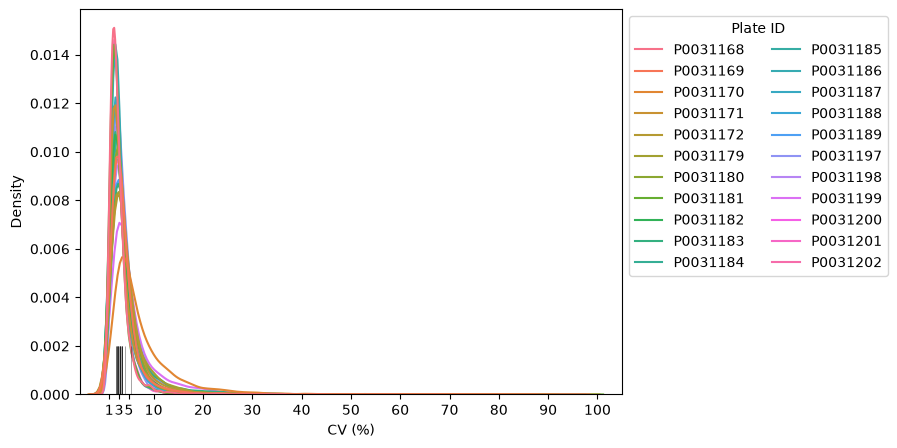

In [8]:
fig = plt.figure(figsize = [7, 5])

ax = sns.kdeplot(
    data=calibrator_cv_by_plate[calibrator_cv_by_plate.cv < 100],
    x="cv",
    hue="PlateId"
)

plt.vlines(
    x = calibrator_cv_by_plate[calibrator_cv_by_plate.cv < 100].groupby("PlateId").cv.median(),
    ymin = 0 , ymax=.002,
    linewidth = .5,
    alpha = .5,
    color = "black"
)

plt.xlabel("CV (%)")
handles = ax.get_legend().legend_handles
labels = [t.get_text() for t in ax.get_legend().get_texts()]
ax.legend(
    handles,
    labels,
    title="Plate ID",
    ncol=2,
    bbox_to_anchor=(1, 1),
    loc="upper left"
)
plt.xticks([1, 3, 5] + list(range(10, 110, 10)))
plt.xlim(-5, 105)

plt.show()

In [9]:
calibrator_cv_by_plate[calibrator_cv_by_plate.cv < 100].groupby("PlateId").cv.median().rename("MedianCV").reset_index().T

,0,1,2,3,4,5,6,7,8,9,...,12,13,14,15,16,17,18,19,20,21
PlateId,P0031168,P0031169,P0031170,P0031171,P0031172,P0031179,P0031180,P0031181,P0031182,P0031183,...,P0031186,P0031187,P0031188,P0031189,P0031197,P0031198,P0031199,P0031200,P0031201,P0031202
MedianCV,2.406665,3.136612,5.382835,2.69628,3.549181,3.497028,3.287475,2.438092,2.829004,3.59213,...,2.642384,2.827859,2.62592,3.467453,3.169942,3.642423,4.151059,2.970622,2.496613,3.201714


Most of the plates fall around 3% CV for the calibrator samples within plate. Out of curiosity, I am also going to derive the between plate CV, but I will first just select a single calibrator sample per plate to make sure the within-plate samples don't affect the estimate.

In [10]:
calibrator_measurements_deduplicated = (
    calibrator_measurements.sort_values(["PlateId", "PlatePosition"])
                           .drop_duplicates(["PlateId", "SeqId"])
)

In [11]:
calibrator_cv_across_plates = (
    100 * calibrator_measurements_deduplicated.groupby("SeqId").value.std() / calibrator_measurements_deduplicated.groupby("SeqId").value.mean()
).rename("cv").to_frame().reset_index()
calibrator_cv_across_plates

,SeqId,cv
0,10000-28,1.649686
1,10001-7,1.824844
2,10003-15,5.187689
3,10006-25,1.746308
4,10008-43,1.527489
...,...,...
7283,9993-11,3.405568
7284,9994-217,1.591657
7285,9995-6,2.003880
7286,9997-12,4.045927


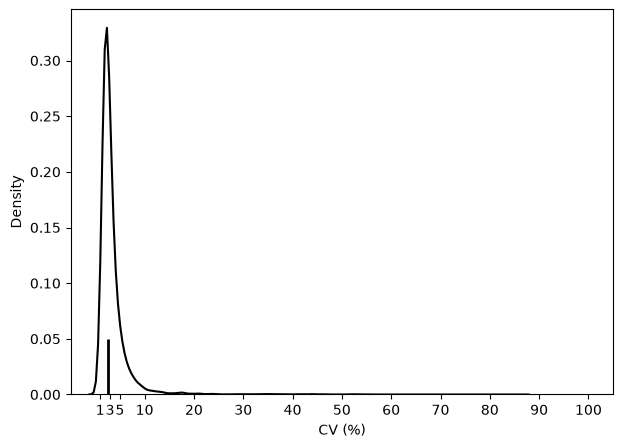

In [12]:
fig = plt.figure(figsize = [7, 5])

ax = sns.kdeplot(
    data=calibrator_cv_across_plates[calibrator_cv_across_plates.cv < 100],
    x="cv",
    c = "black"
)

plt.vlines(
    x = calibrator_cv_across_plates[calibrator_cv_across_plates.cv < 100].cv.median(),
    ymin = 0 , ymax=.05,
    linewidth = 2,
    color = "black"
)
plt.xticks([1, 3, 5] + list(range(10, 110, 10)))

plt.xlabel("CV (%)")
plt.xlim(-5, 105)
plt.show()

In [13]:
calibrator_cv_across_plates[calibrator_cv_across_plates.cv < 100].cv.median()

2.5928423594914376

The CV here also falls below 3. Next, I will see how this matches up to CV estimates from the patient samples themselves.

### Sample Dispersion

In this section I will do a couple filters. In addition to the `SampleType == "Sample"` filter, I will also subset down to `Organism == "Human"` and `Type == "Protein"` on the Somamer dataframe. We could analyze the whole thing but this will focus us in on the Somamers we actually care about.

In [14]:
sample_measurements = (
    samples.loc[samples.SampleType == "Sample", ["PlateId", "PlatePosition"]]
           .merge(measurements)
           .merge(somamer.loc[np.logical_and(somamer.Organism == "Human", somamer.Type == "Protein"), "SeqId"])
)

First, lets check out the amount of replication in this dataset.

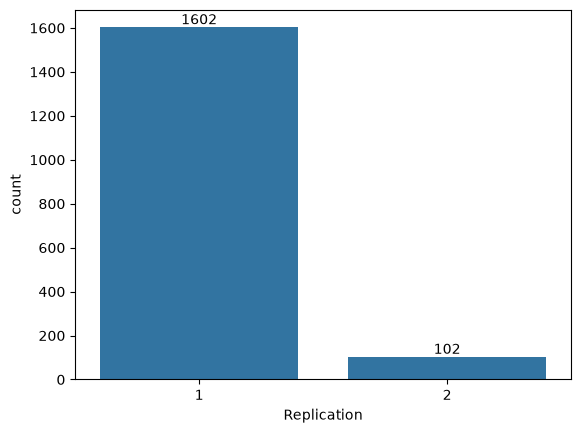

In [15]:
ax = sns.barplot(
    data = (
        samples.loc[samples.SampleType == "Sample", :]
               .SampleId
               .value_counts()
               .rename("Replication")
               .value_counts()
               .to_frame()
    ),
    x = "Replication",
    y = "count"
)

for p in ax.patches:
    ax.annotate(
        int(p.get_height()),
        xy=(p.get_x() + p.get_width()/2, p.get_height()),
            xytext=(0, 5),
            textcoords='offset points', ha="center", va="center")

plt.show()

In [16]:
replicated_samples = samples.loc[samples.SampleType == "Sample", :].SampleId.value_counts().to_frame().reset_index()
replicated_samples = replicated_samples[replicated_samples["count"] > 1]
print("Number of replicated samples:", replicated_samples.shape[0])

Number of replicated samples: 102


We only have 102 samples with replication. This is plenty for estimating CV and shows how much can be packed into a SomaScan dataset while still allowing for some controls.

In Candia, a procedure to calculate the CV of paired samples was presented. Before I try to replicate that, I want to give a sense of why we may want to calculate a CV using paired samples instead of doing the same procedure we did for calibrators. In order to do that, I am going to calculate a CV on the non-replicated samples for each plate.

In [17]:
nonreplicated_sample_measurements = sample_measurements.merge(
    replicated_samples.drop("count", axis = 1).merge(samples).loc[:, ["PlateId", "PlatePosition"]],
    how = "left_anti"
)
nonreplicated_sample_measurements["log2Value"] = np.log2(nonreplicated_sample_measurements["value"])

In [18]:
nonreplicated_sample_cv_by_plate = (
    100 * nonreplicated_sample_measurements.groupby(["PlateId", "SeqId"]).value.std() / nonreplicated_sample_measurements.groupby(["PlateId", "SeqId"]).value.mean()
).rename("cv").to_frame().reset_index()
nonreplicated_sample_cv_by_plate

,PlateId,SeqId,cv
0,P0031168,10000-28,409.978840
1,P0031168,10001-7,25.675626
2,P0031168,10003-15,150.244754
3,P0031168,10006-25,64.958374
4,P0031168,10008-43,34.588950
...,...,...,...
153043,P0031201,9993-11,9.893751
153044,P0031201,9994-217,36.164537
153045,P0031201,9995-6,58.456396
153046,P0031201,9997-12,54.002584


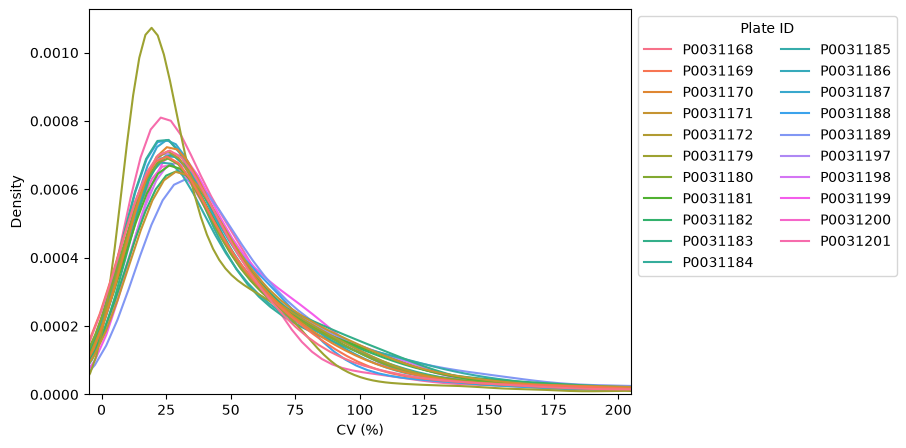

In [19]:
fig = plt.figure(figsize = [7, 5])

ax = sns.kdeplot(
    data=nonreplicated_sample_cv_by_plate,
    x="cv",
    hue="PlateId"
)

plt.xlabel("CV (%)")
handles = ax.get_legend().legend_handles
labels = [t.get_text() for t in ax.get_legend().get_texts()]
ax.legend(
    handles,
    labels,
    title="Plate ID",
    ncol=2,
    bbox_to_anchor=(1, 1),
    loc="upper left"
)
plt.xlim(-5, 205)

plt.show()

In [20]:
nonreplicated_sample_cv_by_plate[nonreplicated_sample_cv_by_plate.cv < 100].groupby("PlateId").cv.median().rename("MedianCV").reset_index().T

,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
PlateId,P0031168,P0031169,P0031170,P0031171,P0031172,P0031179,P0031180,P0031181,P0031182,P0031183,...,P0031185,P0031186,P0031187,P0031188,P0031189,P0031197,P0031198,P0031199,P0031200,P0031201
MedianCV,30.782482,30.450822,32.383063,35.22283,32.030347,26.088106,31.473716,32.248995,34.425474,33.451813,...,31.014419,32.833439,31.919115,31.679681,38.205923,32.385878,34.41672,35.903006,32.319924,30.251106


Compared to the calibrator CV, this is extremely high. This is coming from the fact that the measurements are a mixture of the inter-patient and technical variation, with the former vastly winning out. In order to remove the inter-patient component, we need to correct the data using the pariing of the samples. Since the data is log-normal, we will actually work with fold-change data just like Candia *et al.* did. This has a theoretical distribution that we can utilize for parametric estimates.

In [21]:
replicated_sample_measurements = sample_measurements.merge(
    replicated_samples.drop("count", axis = 1).merge(samples).loc[:, ["PlateId", "PlatePosition"]]
)
replicated_sample_measurements["log2Value"] = np.log2(replicated_sample_measurements["value"])

In [22]:
probe_fold_change = (
    (
        replicated_sample_measurements.merge(
                                          samples.loc[:, ["PlateId", "PlatePosition", "SampleId"]]
                                      ).sort_values(["SampleId", "SeqId", "PlateId"])
                                      .groupby(["SampleId", "SeqId"])
                                      .value
                                      .max()
    ) /
    (
        replicated_sample_measurements.merge(
                                          samples.loc[:, ["PlateId", "PlatePosition", "SampleId"]]
                                      ).sort_values(["SampleId", "SeqId", "PlateId"])
                                      .groupby(["SampleId", "SeqId"])
                                      .value
                                      .min()
    )
).rename("FoldChange")
probe_fold_change = probe_fold_change.reset_index()
probe_fold_change

,SampleId,SeqId,FoldChange
0,1073-17,10000-28,1.022537
1,1073-17,10001-7,1.053305
2,1073-17,10003-15,1.089203
3,1073-17,10006-25,1.058215
4,1073-17,10008-43,1.077004
...,...,...,...
743371,950-20,9993-11,1.019623
743372,950-20,9994-217,1.012786
743373,950-20,9995-6,1.098974
743374,950-20,9997-12,1.137797


I am going to take probe "2682-68" as an example. Candia *et al.* reference an older paper which gives a theoretical distribution for the cumulative number of paired measurements with fold change greater that k and try to match the theoretical distribution to the empirical. In the plot below, I added the theorectical distributions for a probe with a CV of 10% and 20%.

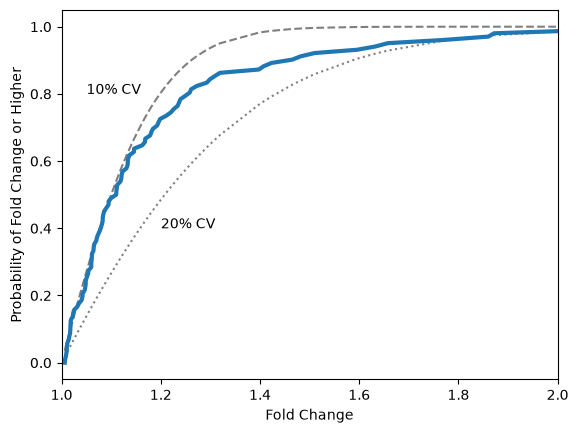

In [23]:
fc = probe_fold_change[probe_fold_change["SeqId"].values == "2682-68"].sort_values("FoldChange")

sns.lineplot(
    x = fc["FoldChange"],
    y = np.arange(fc.shape[0])/fc.shape[0],
    linewidth = 3,
    zorder = 1
)

den = np.sqrt(
    2*np.log(
        np.pow(20/100, 2) + 1
    )
)
prob = 1-2*sc.stats.norm.cdf(-1*np.log(fc["FoldChange"])/den)
sns.lineplot(
    x = fc["FoldChange"],
    y = prob,
    c = "black",
    linestyle = "dotted",
    alpha = .5,
    zorder = 0
)
plt.text(x = 1.2, y = 0.4, s = "20% CV")

den = np.sqrt(
    2*np.log(
        np.pow(10/100, 2) + 1
    )
)
prob = 1-2*sc.stats.norm.cdf(-1*np.log(fc["FoldChange"])/den)
sns.lineplot(
    x = fc["FoldChange"],
    y = prob,
    c = "black",
    linestyle = "dashed",
    alpha = .5,
    zorder = 0
)
plt.text(x = 1.05, y = 0.8, s = "10% CV")

plt.xlabel("Fold Change")
plt.ylabel("Probability of Fold Change or Higher")

plt.xlim(1, 2)
plt.show()

Since the above plot is basically a comparison between and empirical CDF and a series for theoretical CDS, in the text the authors choose to go with a KS statistic criteria for optimizing the CV. Behind the scenes the KS test is looking for the maximum deviation between 2 CDFs and reports the difference in probabilities at that domain value. I have plotted the maximum absoluted deviation point for the 20% CV curve shown by red arrows below.

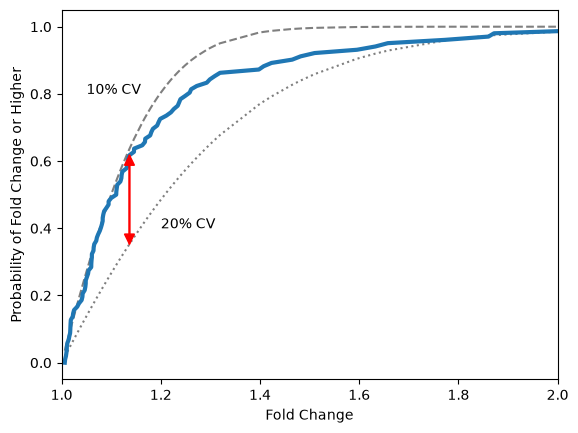

In [24]:
fc = probe_fold_change[probe_fold_change["SeqId"].values == "2682-68"].sort_values("FoldChange")

sns.lineplot(
    x = fc["FoldChange"],
    y = np.arange(fc.shape[0])/fc.shape[0],
    linewidth = 3,
    zorder = 1
)

den = np.sqrt(
    2*np.log(
        np.pow(20/100, 2) + 1
    )
)
prob = 1-2*sc.stats.norm.cdf(-1*np.log(fc["FoldChange"])/den)
sns.lineplot(
    x = fc["FoldChange"],
    y = prob,
    c = "black",
    linestyle = "dotted",
    alpha = .5,
    zorder = 0
)
diff = np.abs(
    prob -
        np.arange(fc.shape[0])/fc.shape[0]
)
argmax = np.argmax(diff)
plt.arrow(
    x = fc["FoldChange"].values[argmax], dx = 0,
    y = prob[argmax], dy = (np.arange(fc.shape[0])/fc.shape[0])[argmax] - prob[argmax],
    head_width=0.02,
    head_length=0.03,
    linewidth=1,
    color='r',
    length_includes_head=True,
    zorder = 2
)
plt.arrow(
    x = fc["FoldChange"].values[argmax], dx = 0,
    y = (np.arange(fc.shape[0])/fc.shape[0])[argmax], dy = prob[argmax] - (np.arange(fc.shape[0])/fc.shape[0])[argmax],
    head_width=0.02,
    head_length=0.03,
    linewidth=1,
    color='r',
    length_includes_head=True,
    zorder = 2
)
plt.text(x = 1.2, y = 0.4, s = "20% CV")

den = np.sqrt(
    2*np.log(
        np.pow(10/100, 2) + 1
    )
)
prob = 1-2*sc.stats.norm.cdf(-1*np.log(fc["FoldChange"])/den)
sns.lineplot(
    x = fc["FoldChange"],
    y = prob,
    c = "black",
    linestyle = "dashed",
    alpha = .5,
    zorder = 0
)
plt.text(x = 1.05, y = 0.8, s = "10% CV")

plt.xlabel("Fold Change")
plt.ylabel("Probability of Fold Change or Higher")

plt.xlim(1, 2)
plt.show()

By doing a line search across the CV space and checking the KS score, we can find the CV value that reports the "minimum maximum absolute deviation". 

In [25]:
def fit_ks(fc):
    fc = np.sort(fc)
    cvs = np.arange(1, 100)
    scores = np.zeros(cvs.shape[0])
    for i in range(len(cvs)):
        den = np.sqrt(
            2*np.log(
                np.pow(cvs[i]/100, 2) + 1
            )
        )
        prob = 2*sc.stats.norm.cdf(-1*np.log(fc)/den)
        diff = np.abs(
            prob -
                np.arange(fc.shape[0])[::-1]/fc.shape[0]
        )
        scores[i] = np.max(diff)

    return cvs, scores

cvs_ks, scores_ks = fit_ks(fc["FoldChange"])

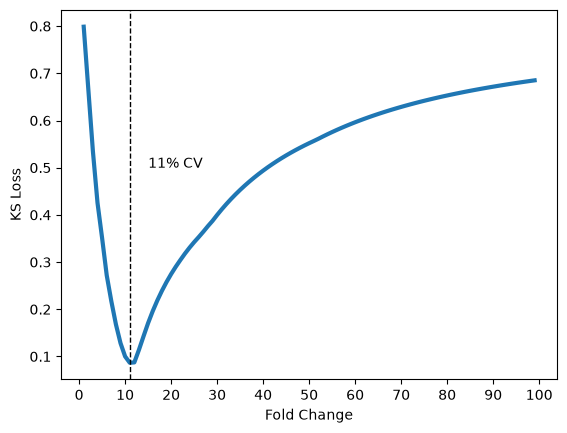

In [26]:
argmin_ks = np.argmin(scores_ks)

sns.lineplot(
    x = cvs_ks,
    y = scores_ks,
    linewidth = 3
)
plt.axvline(
    x = cvs_ks[argmin_ks],
    ymin = 0,
    ymax = 1,
    linewidth = 1,
    linestyle = "dashed",
    color = "black"
)

plt.text(
    x = 15,
    y = 0.5,
    s = f"{cvs_ks[argmin_ks]}% CV"
)

plt.xticks(range(0, 101, 10))
plt.xlabel("Fold Change")
plt.ylabel("KS Loss")

plt.show()

What worries me however is that this isn't the usual go to estimator for the CV in this case. A maximum likelihood estimate may be a bit better and comes directly from the distribution itself. I go into depth about the derivation of this PDF in the `2026_09_15_factor_distribution` notebook, but I repeat the formula below for $x = absolute Natural Log Fold Change$. A correction is available if you want log2 fold change but this version is easier to work with and gives the same result.

$$ f(x) = \frac{1}{\sqrt{\pi \log(\theta^{2}+1)}} \exp\left(-\frac{x^{2}}{4\log(\theta^{2}+1)}\right), \quad x > 0 $$

A line search optimizing this curve is shown below.

In [27]:
def factor_pdf(fold_change, cv):
    """PDF of the fold change Y/X (larger over smaller) for two i.i.d. log-normal measurements with percent CV."""
    fold_change = np.asarray(fold_change)
    theta = cv / 100
    x = np.abs(np.log(fold_change))
    log_term = np.log(theta**2 + 1)
    return 1.0 / np.sqrt(np.pi * log_term) * np.exp(-(x**2) / (4 * log_term))

def fit_ml(fc):
    fc = np.sort(fc)
    cvs = np.arange(2, 100)
    scores = np.zeros(cvs.shape[0])
    for i in range(len(cvs)):
        scores[i] = -np.sum(
            np.log(
                factor_pdf(fc, cvs[i])
            )
        )

    return cvs, scores

cvs_ml, scores_ml = fit_ml(fc["FoldChange"])
cvs_ml, scores_ml = cvs_ml[scores_ml < 0], scores_ml[scores_ml < 0]

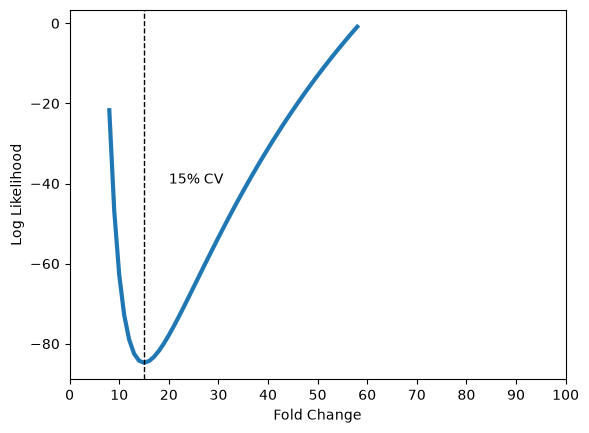

In [28]:
argmin_ml = np.argmin(scores_ml)

sns.lineplot(
    x = cvs_ml,
    y = scores_ml,
    linewidth = 3
)
plt.axvline(
    x = cvs_ml[argmin_ml],
    ymin = 0,
    ymax = 1,
    linewidth = 1,
    linestyle = "dashed",
    color = "black"
)

plt.text(
    x = 20,
    y = -40,
    s = f"{cvs_ml[argmin_ml]}% CV"
)

plt.xticks(range(0, 101, 10))
plt.xlabel("Fold Change")
plt.ylabel("Log Likelihood")

plt.show()

These are clearly quite a bit off from each other. Looking back at the theoretical CDFs, I think the second estimate does a bit better at balancing error across the distribution. However, I think only a monte carlo study would give a definitive answer as to which estimator had better properties.

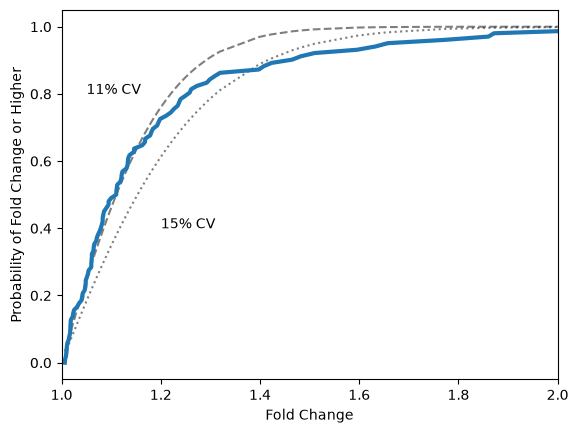

In [29]:
fc = probe_fold_change[probe_fold_change["SeqId"].values == "2682-68"].sort_values("FoldChange")

sns.lineplot(
    x = fc["FoldChange"],
    y = np.arange(fc.shape[0])/fc.shape[0],
    linewidth = 3,
    zorder = 1
)

den = np.sqrt(
    2*np.log(
        np.pow(15/100, 2) + 1
    )
)
prob = 1-2*sc.stats.norm.cdf(-1*np.log(fc["FoldChange"])/den)
sns.lineplot(
    x = fc["FoldChange"],
    y = prob,
    c = "black",
    linestyle = "dotted",
    alpha = .5,
    zorder = 0
)
diff = np.abs(
    prob -
        np.arange(fc.shape[0])/fc.shape[0]
)
plt.text(x = 1.2, y = 0.4, s = "15% CV")

den = np.sqrt(
    2*np.log(
        np.pow(11/100, 2) + 1
    )
)
prob = 1-2*sc.stats.norm.cdf(-1*np.log(fc["FoldChange"])/den)
sns.lineplot(
    x = fc["FoldChange"],
    y = prob,
    c = "black",
    linestyle = "dashed",
    alpha = .5,
    zorder = 0
)
plt.text(x = 1.05, y = 0.8, s = "11% CV")

plt.xlabel("Fold Change")
plt.ylabel("Probability of Fold Change or Higher")

plt.xlim(1, 2)
plt.show()

Another nice part about the maximum likelihood estimator is that it has a closed form solution, which simplifies computation a bit as well. I derive this in `2026_09_15_factor_distribution` as well.

$$ \hat{\theta}_{mle} = \sqrt{\exp\left(\frac{1}{2}\hat{\sigma}_{mle}^2\right) - 1} = \sqrt{\exp\left(\frac{1}{2N}\sum_{i=1}^{N} x_i^{2}\right) - 1} $$

Using this, I will get an estimate across the data of the CV for all of the probes.

In [30]:
def factor_mle(fold_change):
    """Maximum likelihood estimate of the percent CV from an array of fold changes (Y/X, larger over smaller)."""
    fold_change = np.asarray(fold_change)
    x = np.log(fold_change)
    theta = np.sqrt(np.exp(np.mean(x**2) / 2) - 1)
    return theta * 100

probe_cvs_ml = (
    probe_fold_change.head(306).groupby("SeqId")
                     .apply(
                         lambda df: factor_mle(df["FoldChange"])
                     ).rename("cv")
                     .reset_index()
)

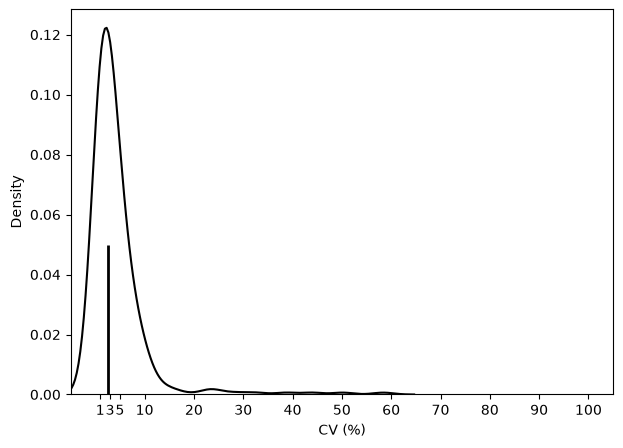

In [31]:
fig = plt.figure(figsize = [7, 5])

ax = sns.kdeplot(
    data=probe_cvs_ml[probe_cvs_ml.cv < 100],
    x="cv",
    c = "black"
)

plt.vlines(
    x = probe_cvs_ml[probe_cvs_ml.cv < 100].cv.median(),
    ymin = 0 , ymax=.05,
    linewidth = 2,
    color = "black"
)
plt.xticks([1, 3, 5] + list(range(10, 110, 10)))

plt.xlabel("CV (%)")
plt.xlim(-5, 105)
plt.show()

In [32]:
probe_cvs_ml[probe_cvs_ml.cv < 100].cv.median()

2.6297478871231537

And here we arive back at our nice 2.6 % CV that matches fairly closely to what we got on calibrators.